In [43]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
data_dir = PROJECT_ROOT/"results"
section = "00"
source_normal_errors = np.load(data_dir/f"section_{section}_source_normal_errors.npy")
source_anomaly_errors = np.load(data_dir/f"section_{section}_source_anomaly_errors.npy")
threshold = np.load(data_dir/f"section_{section}_threshold.npy").item()


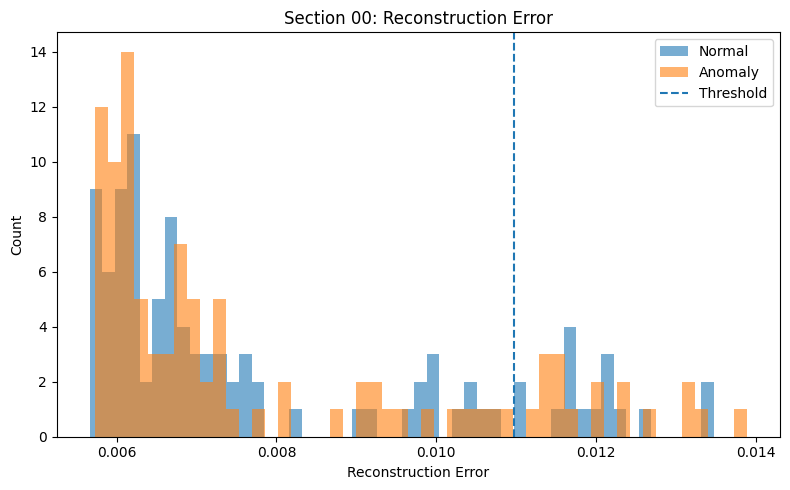

In [44]:
plt.figure(figsize=(8, 5))

plt.hist(
    source_normal_errors,
    bins=50,
    alpha=0.6,
    label="Normal",
)

plt.hist(
    source_anomaly_errors,
    bins=50,
    alpha=0.6,
    label="Anomaly",
)

plt.axvline(
    threshold,
    linestyle="--",
    label="Threshold",
)

plt.xlabel("Reconstruction Error")
plt.ylabel("Count")
plt.title(
    f"Section {section}: Reconstruction Error"
)

plt.legend()

plt.tight_layout()

plt.show()


In [45]:


print("Normal")
print("mean:", np.mean(source_normal_errors))
print("median:", np.median(source_normal_errors))
print("std:", np.std(source_normal_errors))

print()

print("Anomaly")
print("mean:", np.mean(source_anomaly_errors))
print("median:", np.median(source_anomaly_errors))
print("std:", np.std(source_anomaly_errors))

Normal
mean: 0.007837129
median: 0.0067541725
std: 0.0022498386

Anomaly
mean: 0.00784627
median: 0.006795888
std: 0.0023203907


In [46]:
from scipy.stats import mannwhitneyu

stat, p_value = mannwhitneyu(
    source_normal_errors,
    source_anomaly_errors,
    alternative="two-sided"
)

print("U statistic:", stat)
print("p-value:", p_value)

U statistic: 5050.0
p-value: 0.9037324207897961


In [47]:
def cohens_d(x, y):
    nx = len(x)
    ny = len(y)

    pooled_std = np.sqrt(
        (
            (nx - 1) * np.var(x, ddof=1)
            +
            (ny - 1) * np.var(y, ddof=1)
        )
        /
        (nx + ny - 2)
    )

    return (
        np.mean(x) - np.mean(y)
    ) / pooled_std


d = cohens_d(
    source_anomaly_errors,
    source_normal_errors
)

print("Cohen's d:", d)

Cohen's d: 0.003979681


In [ ]:
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import sys

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import (
    load_audio,
    compute_mel_spectrogram,
    resize_spectrogram
)
from src.train import AcousticDataset, train_autoencoder
from src.models import CNNAutoencoder

model = CNNAutoencoder()

device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

model = model.to(device)
model.eval()

CNNAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Upsample(scale_factor=2.0, mode='bilinear')
    (1): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (2): ReLU()
    (3): Upsample(scale_factor=2.0, mode='bilinear')
    (4): Conv2d(32, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
    (6): Upsample(scale_factor=2.0, mode='bilinear')
    (7): Conv2d(16, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): Sigmoid()
  )
)

torch.Size([1, 128, 320])
tensor(0.3687)
tensor(1.)
tensor(0.6792)
tensor(0.0976)


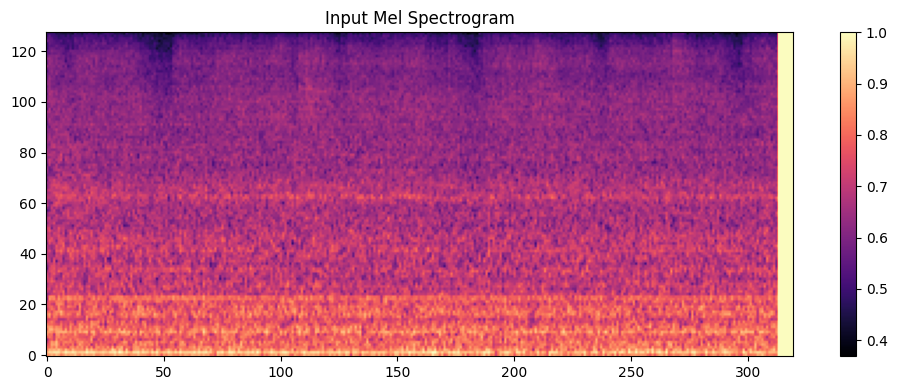

In [49]:
train_dir = PROJECT_ROOT/"data/dev_data_fan/train"
source_train = sorted(train_dir.glob("*.wav"))[:1000]
dataset = AcousticDataset(source_train)


x = dataset[0]

print(x.shape)
print(x.min())
print(x.max())
print(x.mean())
print(x.std())

plt.figure(figsize=(10, 4))

plt.imshow(
    x.squeeze().numpy(),
    origin="lower",
    aspect="auto",
    cmap="magma"
)

plt.colorbar()
plt.title("Input Mel Spectrogram")
plt.tight_layout()
plt.show()

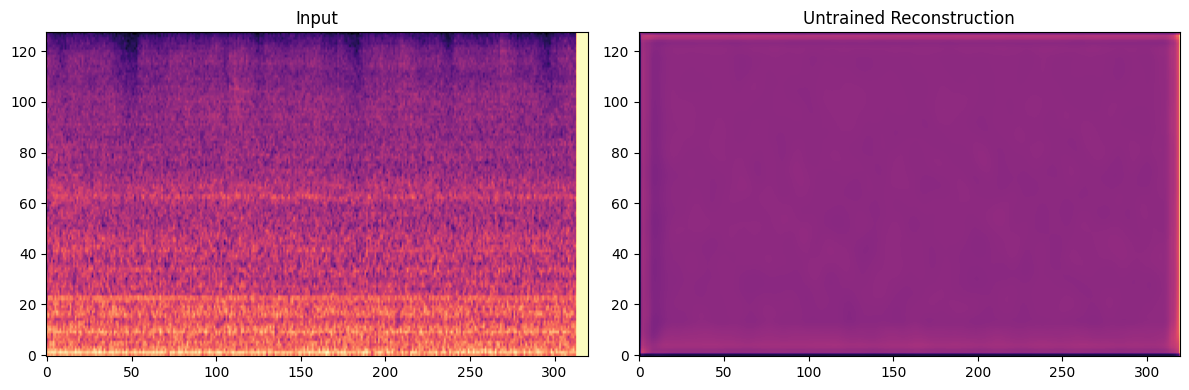

In [30]:
model = CNNAutoencoder()


x = dataset[0].unsqueeze(0)

with torch.no_grad():
    reconstruction = model(x)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(
    x.squeeze().numpy(),
    origin="lower",
    aspect="auto",
    cmap="magma"
)

axes[0].set_title("Input")

axes[1].imshow(
    reconstruction.squeeze().numpy(),
    origin="lower",
    aspect="auto",
    cmap="magma"
)

axes[1].set_title("Untrained Reconstruction")

plt.tight_layout()
plt.show()

torch.Size([1, 1, 128, 320])
torch.Size([1, 1, 1024, 2560])


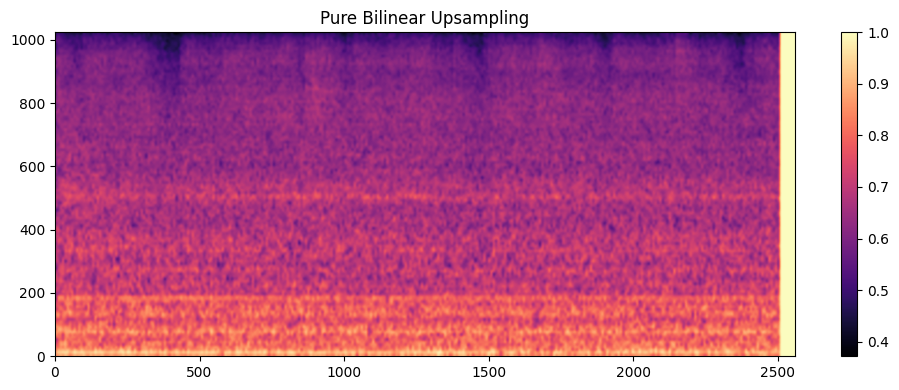

In [31]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

x = dataset[0].unsqueeze(0)

upsample = nn.Upsample(
    scale_factor=2,
    mode="bilinear",
    align_corners=False
)

y = upsample(x)

y = upsample(y)

y = upsample(y)

print(x.shape)
print(y.shape)

plt.figure(figsize=(10, 4))

plt.imshow(
    y[0, 0].detach().numpy(),
    origin="lower",
    aspect="auto",
    cmap="magma"
)

plt.colorbar()
plt.title("Pure Bilinear Upsampling")
plt.tight_layout()
plt.show()

In [56]:
from pathlib import Path
import torch

from src.models import CNNAutoencoder

PROJECT_ROOT = Path.cwd().parent
MODEL_PATH = PROJECT_ROOT / "results" / "cnn_ae_section_00_source.pth"
data_root = Path(PROJECT_ROOT/"data/dev_data_fan")

source_test = list((data_root / "source_test").glob("*.wav"))

device = torch.device(
    "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)

model = CNNAutoencoder()

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=device
    )
)

model = model.to(device)
model.eval()


normal_files = [
    f for f in source_test
    if "normal" in f.name
]

anomaly_files = [
    f for f in source_test
    if "anomaly" in f.name
]

normal_file = normal_files[0]
anomaly_file = anomaly_files[0]

print(normal_file)
print(anomaly_file)

/Applications/FAU/Application/Akustische_industriellen_Kontexten/data/dev_data_fan/source_test/section_00_source_test_normal_0048.wav
/Applications/FAU/Application/Akustische_industriellen_Kontexten/data/dev_data_fan/source_test/section_02_source_test_anomaly_0090.wav


/var/folders/17/6p16j4v96t50lw78snlh7yrw0000gn/T/ipykernel_5469/3407786951.py:21: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load(


In [57]:
def prepare_input(file_path):

    audio, sr = load_audio(file_path, sr=16000)

    mel = compute_mel_spectrogram(audio, sr, n_mels=128)

    mel = resize_spectrogram(mel, target_frames=320)

    mel = (mel + 80.0) / 80.0
    mel = np.clip(mel, 0.0, 1.0)

    tensor = torch.tensor(mel, dtype=torch.float32)

    tensor = tensor.unsqueeze(0)
    tensor = tensor.unsqueeze(0)

    return tensor

Original:
  min: 0.33311734
  max: 1.0
  mean: 0.6573483
Reconstruction:
  min: 0.3505381
  max: 1.0
  mean: 0.6588588
Error:
  min: 0.0
  max: 0.21955937
  mean: 0.028857436


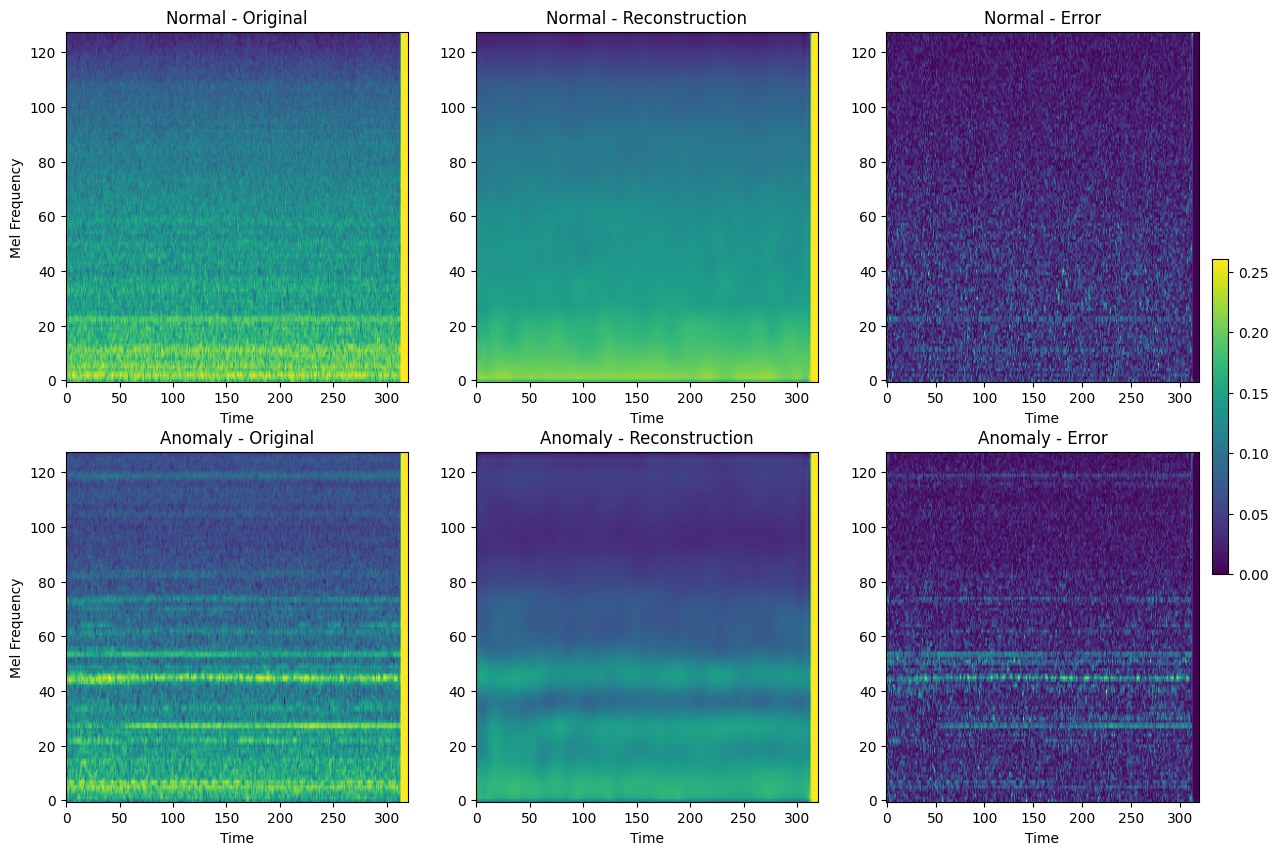

In [58]:
def reconstruct(model, file_path, device):

    x = prepare_input(file_path).to(device)

    with torch.no_grad():
        y = model(x)

    original = (
        x.squeeze()
        .cpu()
        .numpy()
    )

    reconstructed = (
        y.squeeze()
        .cpu()
        .numpy()
    )

    error = np.abs(
        original - reconstructed
    )

    return (
        original,
        reconstructed,
        error
    )

model.eval()
normal_original, normal_recon, normal_error = reconstruct(
    model,
    normal_file,
    device
)

anomaly_original, anomaly_recon, anomaly_error = reconstruct(
    model,
    anomaly_file,
    device
)

print("Original:")
print("  min:", normal_original.min())
print("  max:", normal_original.max())
print("  mean:", normal_original.mean())

print("Reconstruction:")
print("  min:", normal_recon.min())
print("  max:", normal_recon.max())
print("  mean:", normal_recon.mean())

print("Error:")
print("  min:", normal_error.min())
print("  max:", normal_error.max())
print("  mean:", normal_error.mean())

fig, axes = plt.subplots(2,3,figsize=(15, 10))

data = [
    (
        normal_original,
        normal_recon,
        normal_error,
        "Normal"
    ),
    (
        anomaly_original,
        anomaly_recon,
        anomaly_error,
        "Anomaly"
    )
]

for row, (
    original,
    reconstruction,
    error,
    label
) in enumerate(data):

    axes[row, 0].imshow(
        original,
        aspect="auto",
        origin="lower"
    )

    axes[row, 0].set_title(
        f"{label} - Original"
    )

    axes[row, 1].imshow(
        reconstruction,
        aspect="auto",
        origin="lower"
    )

    axes[row, 1].set_title(
        f"{label} - Reconstruction"
    )

    im = axes[row, 2].imshow(
        error,
        aspect="auto",
        origin="lower"
    )

    axes[row, 2].set_title(
        f"{label} - Error"
    )

    axes[row, 0].set_ylabel(
        "Mel Frequency"
    )

    for col in range(3):
        axes[row, col].set_xlabel(
            "Time"
        )

fig.colorbar(
    im,
    ax=axes[:, 2],
    fraction=0.046,
    pad=0.04,
    location="right"
)

plt.show()